In [2]:
# ============================================
# IMPORTATION DES BIBLIOTHÈQUES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" Bibliothèques importées avec succès !")

 Bibliothèques importées avec succès !


In [3]:
# ============================================
# CHARGEMENT DES DONNÉES
# ============================================

# Noms des colonnes car le fichier n'a pas d'en-tête
colonnes = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
            'restecg', 'thalach', 'exang', 'oldpeak', 
            'slope', 'ca', 'thal', 'target']

# Chargement du fichier
df = pd.read_csv('processed.cleveland.data', 
                  names=colonnes, 
                  na_values='?')

print("Dimensions du dataset :", df.shape)
print("\nApercu des 5 premieres lignes :")
df.head()

Dimensions du dataset : (303, 14)

Apercu des 5 premieres lignes :


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# ============================================
# EXPLORATION INITIALE DES DONNEES
# ============================================

print("--- Informations generales ---")
print(df.info())

print("\n--- Statistiques descriptives ---")
print(df.describe())

print("\n--- Valeurs manquantes par colonne ---")
print(df.isnull().sum())

--- Informations generales ---
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

--- Statistiques descriptives ---
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000 

In [5]:
# ============================================
# NETTOYAGE DES DONNEES
# ============================================

# Suppression des lignes avec valeurs manquantes
# On perd seulement 6 lignes sur 303, c'est negligeable
df = df.dropna()
print("Dimensions apres suppression des valeurs manquantes :", df.shape)

# Transformation de target en binaire
# 0 = pas de maladie, 1 = maladie (peu importe le niveau de severite)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("\nDistribution de la variable cible apres transformation :")
print(df['target'].value_counts())
print("\n0 = Pas de maladie cardiaque")
print("1 = Maladie cardiaque")

Dimensions apres suppression des valeurs manquantes : (297, 14)

Distribution de la variable cible apres transformation :
target
0    160
1    137
Name: count, dtype: int64

0 = Pas de maladie cardiaque
1 = Maladie cardiaque


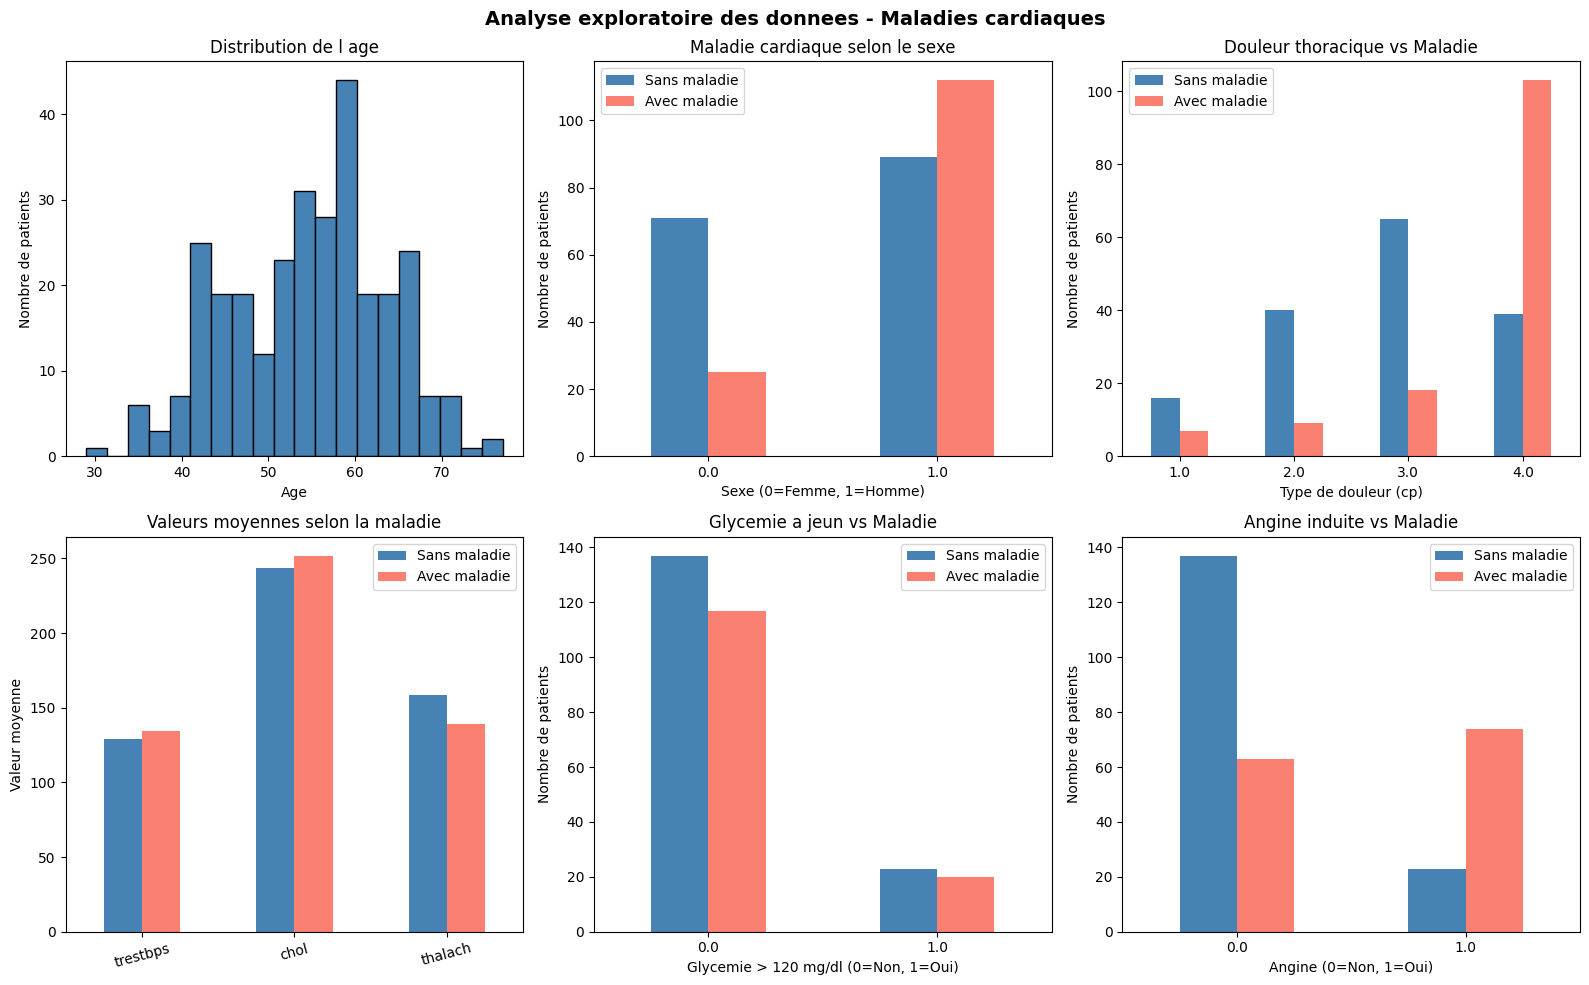

Graphique sauvegarde avec succes


In [6]:
# ============================================
# ANALYSE EXPLORATOIRE DES DONNEES
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Analyse exploratoire des donnees - Maladies cardiaques', 
             fontsize=14, fontweight='bold')

# --- Question 1 : Distribution de l'age ---
axes[0,0].hist(df['age'], bins=20, color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribution de l age')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Nombre de patients')

# --- Question 2 : Maladie cardiaque selon le sexe ---
sex_target = df.groupby(['sex', 'target']).size().unstack()
sex_target.plot(kind='bar', ax=axes[0,1], color=['steelblue', 'salmon'])
axes[0,1].set_title('Maladie cardiaque selon le sexe')
axes[0,1].set_xlabel('Sexe (0=Femme, 1=Homme)')
axes[0,1].set_ylabel('Nombre de patients')
axes[0,1].legend(['Sans maladie', 'Avec maladie'])
axes[0,1].tick_params(axis='x', rotation=0)

# --- Question 3 : Type de douleur thoracique et maladie ---
cp_target = df.groupby(['cp', 'target']).size().unstack()
cp_target.plot(kind='bar', ax=axes[0,2], color=['steelblue', 'salmon'])
axes[0,2].set_title('Douleur thoracique vs Maladie')
axes[0,2].set_xlabel('Type de douleur (cp)')
axes[0,2].set_ylabel('Nombre de patients')
axes[0,2].legend(['Sans maladie', 'Avec maladie'])
axes[0,2].tick_params(axis='x', rotation=0)

# --- Question 4 : Valeurs moyennes selon la maladie ---
moyennes = df.groupby('target')[['trestbps', 'chol', 'thalach']].mean()
moyennes.T.plot(kind='bar', ax=axes[1,0], color=['steelblue', 'salmon'])
axes[1,0].set_title('Valeurs moyennes selon la maladie')
axes[1,0].set_ylabel('Valeur moyenne')
axes[1,0].legend(['Sans maladie', 'Avec maladie'])
axes[1,0].tick_params(axis='x', rotation=15)

# --- Question 5 : Glycemie a jeun et maladie ---
fbs_target = df.groupby(['fbs', 'target']).size().unstack()
fbs_target.plot(kind='bar', ax=axes[1,1], color=['steelblue', 'salmon'])
axes[1,1].set_title('Glycemie a jeun vs Maladie')
axes[1,1].set_xlabel('Glycemie > 120 mg/dl (0=Non, 1=Oui)')
axes[1,1].set_ylabel('Nombre de patients')
axes[1,1].legend(['Sans maladie', 'Avec maladie'])
axes[1,1].tick_params(axis='x', rotation=0)

# --- Question 6 : Angine et maladie ---
exang_target = df.groupby(['exang', 'target']).size().unstack()
exang_target.plot(kind='bar', ax=axes[1,2], color=['steelblue', 'salmon'])
axes[1,2].set_title('Angine induite vs Maladie')
axes[1,2].set_xlabel('Angine (0=Non, 1=Oui)')
axes[1,2].set_ylabel('Nombre de patients')
axes[1,2].legend(['Sans maladie', 'Avec maladie'])
axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('analyse_exploratoire.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde avec succes")

In [7]:
# ============================================
# PREPARATION DES DONNEES POUR LE ML
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separation features (X) et cible (y)
# X = toutes les colonnes sauf target
# y = uniquement target
X = df.drop('target', axis=1)
y = df['target']

print("Taille de X (features) :", X.shape)
print("Taille de y (cible) :", y.shape)

# Division en ensemble d'entrainement (80%) et de test (20%)
# random_state=42 garantit qu'on obtient toujours la meme division
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTaille ensemble entrainement :", X_train.shape)
print("Taille ensemble test :", X_test.shape)

# Normalisation des donnees
# StandardScaler met toutes les colonnes a la meme echelle
# moyenne=0 et ecart-type=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nNormalisation effectuee avec succes")
print("Les donnees sont pretes pour le machine learning")

Taille de X (features) : (297, 13)
Taille de y (cible) : (297,)

Taille ensemble entrainement : (237, 13)
Taille ensemble test : (60, 13)

Normalisation effectuee avec succes
Les donnees sont pretes pour le machine learning


In [8]:
# ============================================
# ENTRAINEMENT ET EVALUATION DES 6 ALGORITHMES
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                              recall_score, f1_score, roc_auc_score)

# Definition des 6 modeles
modeles = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'SVM'                : SVC(random_state=42, probability=True),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(random_state=42, n_estimators=100),
    'AdaBoost'           : AdaBoostClassifier(random_state=42, n_estimators=100)
}

# Dictionnaire pour stocker les resultats
resultats = {}

print("Entrainement des modeles en cours...\n")

for nom, modele in modeles.items():
    # Entrainement sur les donnees d'entrainement
    modele.fit(X_train_scaled, y_train)
    
    # Prediction sur les donnees de test
    y_pred = modele.predict(X_test_scaled)
    y_proba = modele.predict_proba(X_test_scaled)[:, 1]
    
    # Calcul des metriques
    resultats[nom] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Rappel'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_proba), 4)
    }
    print(f"{nom} : OK")

# Affichage sous forme de tableau
df_resultats = pd.DataFrame(resultats).T
print("\n--- Tableau comparatif des performances ---")
print(df_resultats)

Entrainement des modeles en cours...

Logistic Regression : OK
KNN : OK
SVM : OK
Decision Tree : OK
Random Forest : OK
AdaBoost : OK

--- Tableau comparatif des performances ---
                     Accuracy  Precision  Rappel  F1-Score  AUC-ROC
Logistic Regression    0.8333     0.8462  0.7857    0.8148   0.9498
KNN                    0.8833     0.9200  0.8214    0.8679   0.9492
SVM                    0.8500     0.8800  0.7857    0.8302   0.9542
Decision Tree          0.6833     0.6800  0.6071    0.6415   0.6786
Random Forest          0.8667     0.8846  0.8214    0.8519   0.9414
AdaBoost               0.8500     0.8519  0.8214    0.8364   0.9241


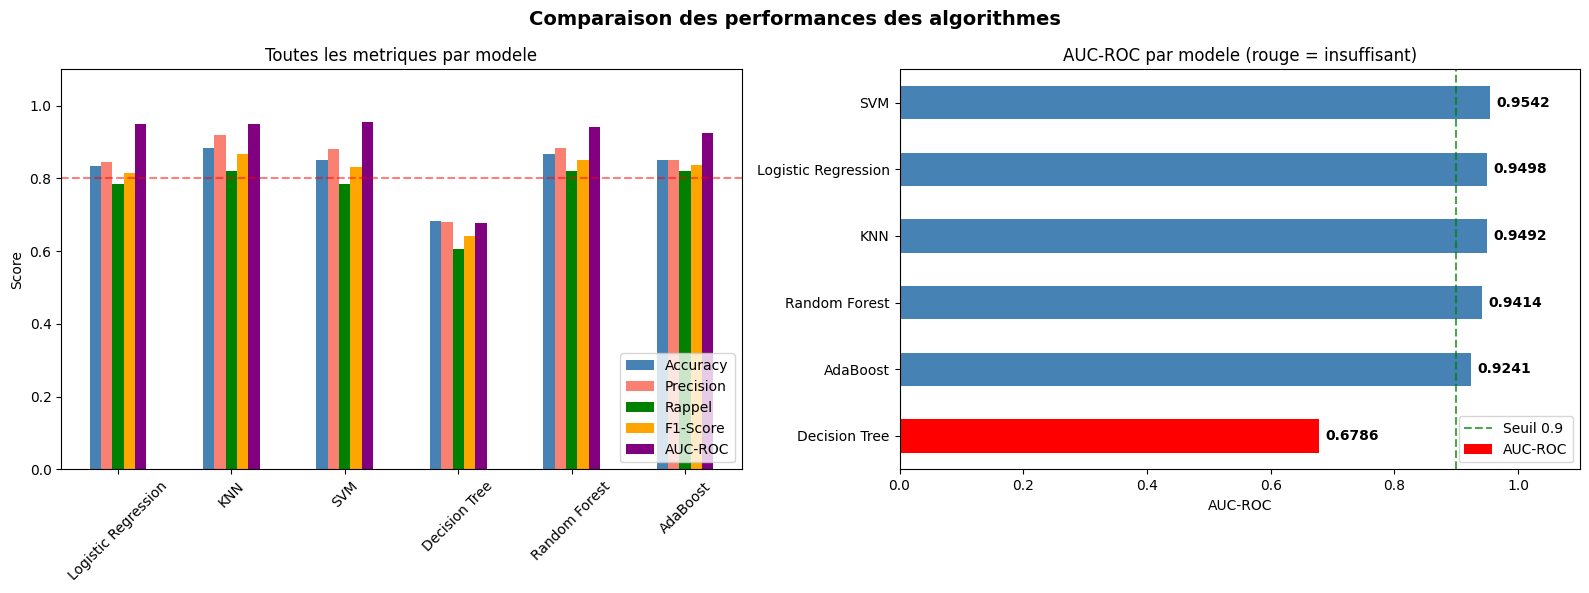

Graphique sauvegarde avec succes


In [9]:
# ============================================
# VISUALISATION DES PERFORMANCES
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparaison des performances des algorithmes', 
             fontsize=14, fontweight='bold')

# --- Graphique 1 : Toutes les metriques par modele ---
df_resultats.plot(kind='bar', ax=axes[0], 
                   color=['steelblue','salmon','green','orange','purple'])
axes[0].set_title('Toutes les metriques par modele')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='lower right')
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Seuil 0.8')

# --- Graphique 2 : AUC-ROC uniquement ---
auc_values = df_resultats['AUC-ROC'].sort_values(ascending=True)
colors = ['red' if v < 0.8 else 'steelblue' for v in auc_values]
auc_values.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('AUC-ROC par modele (rouge = insuffisant)')
axes[1].set_xlabel('AUC-ROC')
axes[1].set_xlim(0, 1.1)
axes[1].axvline(x=0.9, color='green', linestyle='--', alpha=0.7, label='Seuil 0.9')
axes[1].legend()

for i, v in enumerate(auc_values):
    axes[1].text(v + 0.01, i, str(round(v, 4)), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde avec succes")

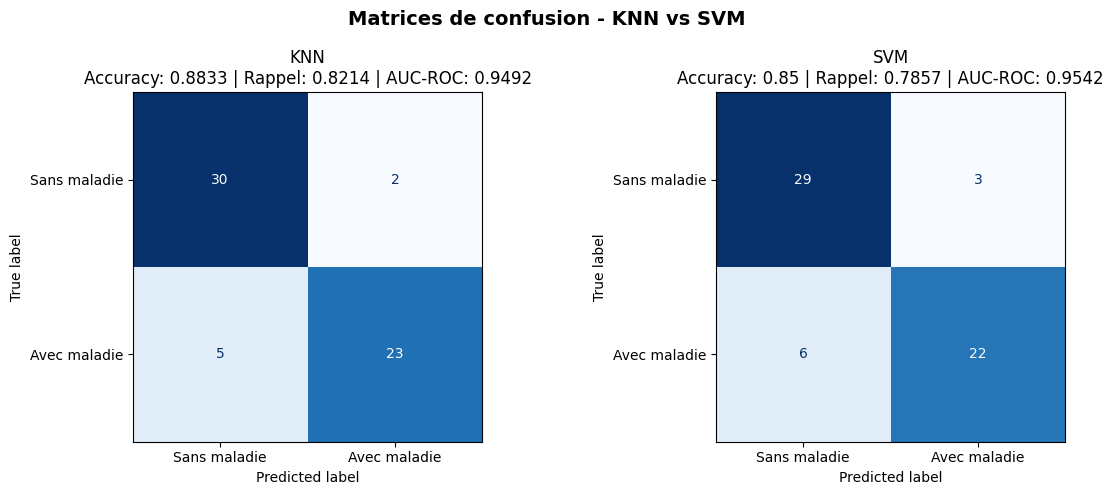

Graphique sauvegarde avec succes


In [10]:
# ============================================
# MATRICES DE CONFUSION - 2 MEILLEURS MODELES
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Matrices de confusion - KNN vs SVM', 
             fontsize=14, fontweight='bold')

meilleurs_modeles = ['KNN', 'SVM']

for i, nom in enumerate(meilleurs_modeles):
    modele = modeles[nom]
    y_pred = modele.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Sans maladie', 'Avec maladie'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{nom}\nAccuracy: {resultats[nom]["Accuracy"]} | '
                      f'Rappel: {resultats[nom]["Rappel"]} | '
                      f'AUC-ROC: {resultats[nom]["AUC-ROC"]}')

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde avec succes")